<a href="https://colab.research.google.com/github/saramarialangner/Computational-Physics/blob/main/1_mlp_from_scratch_SML_AHY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training a multilayer perceptron from scratch, in JAX

Build an MLP out of nothing but arrays — the parameters, the forward pass, the optimizers, and the training
loop. `jax.grad` gives you backpropagation; write everything else yourself.

The target is a sum of four sine waves of **equal amplitude** at frequencies 1, 2, 4 and 8.

In [2]:
# !pip install -q jax jaxlib matplotlib

import time
import jax
from jax import grad, jit, vmap
from jax import random
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

print("jax", jax.__version__, "| devices:", jax.devices())

jax 0.11.1 | devices: [CpuDevice(id=0)]


## The data


In [3]:
FREQS = jnp.array([1.0, 2.0, 4.0, 8.0])
NOISE_STD = 0.02


def target_fn(x):
    """x: (n,) -> (n,)"""
    return jnp.mean(jnp.sin(2 * jnp.pi * FREQS * x[:, None]), axis=-1)


def make_data(key, n=2048, noise_std=NOISE_STD):
    """Returns X: (n, 1), Y: (n, 1)"""
    key_x, key_noise = jax.random.split(key)
    x = jax.random.uniform(key_x, (n,), minval=0.0, maxval=1.0)
    y = target_fn(x) + noise_std * jax.random.normal(key_noise, (n,))
    return x[:, None], y[:, None]


X, Y = make_data(jax.random.key(0))

print(f"X shape: {X.shape}")
print(f"X: {X}")
print(f"target variance : {float(Y.var()):.4f}")   # silly baseline: the error you get by predicting the mean

X shape: (2048, 1)
X: [[0.8423141 ]
 [0.18237865]
 [0.2271781 ]
 ...
 [0.16758251]
 [0.32603884]
 [0.3397516 ]]
target variance : 0.1236


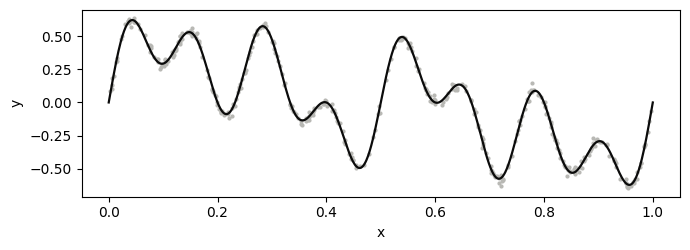

In [4]:
grid = jnp.linspace(0, 1, 1000)
plt.figure(figsize=(7, 2.6))
plt.scatter(np.array(X[:400, 0]), np.array(Y[:400, 0]), s=4, color="#b8b8b4")
plt.plot(np.array(grid), np.array(target_fn(grid)), color="#0b0b0b", lw=1.6)
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()

---
## 1. The network

Write three functions:

- `init_mlp(key, layer_sizes)` — the parameters. Think about what a layer actually *is*, and about the scale
  of the initial random draw.
- `forward(params, x)` — `activation` on the hidden layers, nothing on the output.
- `loss_fn(params, x, y)` — mean squared error.

Use `[1, 128, 128, 1]`.

In [5]:
#Build Linear Transformation to use for stacking multiple layeers later

def init_linear(key, in_features, out_features):
    """Provide random data for weights W and biases b"""
    k1, k2 = random.split(key)
    # Xavier initialization
    scale = jnp.sqrt(2.0 / (in_features + out_features))
    W = random.normal(k1, (out_features, in_features)) * scale
    b = jnp.zeros((out_features)) # make sure b has same dimension as input if using multidim imput (see test)
    return {'W': W, 'b': b}

def linear(params, x):
    """Apply linear transformation."""
    return params['W'] @ x + params['b']

# Test
key = random.PRNGKey(0) #exact key values for init_linear()
linear_params = init_linear(key, in_features=2048, out_features=2048)
x,y = make_data(jax.random.key(0))

print(f"Verifying Linear Transformation architecture:")
print(f"  Input shape: {x.shape}")
print(f"  W shape: {linear_params['W'].shape}")
print(f"  b shape: {linear_params['b'].shape}")
print(f"  Output shape: {linear(linear_params, x).shape}")
print(f"  Output: {linear(linear_params, x)}")

#Build MLP
#Define parameters for MLP with one data input

def init_mlp(key, layer_sizes):
  """layer_sizes=[input_dim, hidden1, hidden2, ..., hiddenN, output_dim]=[1,128,128,1] here for each datapoint out of the 2048

  want to store all parameters for one datapoint in each layer with init_linear()
  """

  params=[]
  keys = random.split(key, len(layer_sizes) - 1) #have to define keys - why -1? - not needed for last layer

  for i, (key, in_size, out_size) in enumerate(           #define new variable for looping through in and out features per datapoint
        zip(keys, layer_sizes[:-1], layer_sizes[1:])):
      params.append(init_linear(key, in_size, out_size)) #zip() give element by element combination of key, layer input and layer_output
  return params

#Introduce nonlinearity with activation function
def forward(params, x, activation=jax.nn.relu):
  for layer_params in params[:-1]: #omit last layer
      x=activation(linear(layer_params, x))
    # No activation on final layer; so just linear on previous last layer
  return linear(params[-1], x)

#Test
key = random.PRNGKey(42)
mlp_params = init_mlp(key, [1, 128, 128, 1])  # 1 inputs, 2 hidden layers of length 128, 1 output

print(f" ")
print("Verifying Single Input MLP architecture:")
for i, p in enumerate(mlp_params):
    print(f"  Layer {i}: W shape = {p['W'].shape}")

x=X[0]

y = forward(mlp_params, x)
print(f"  Input: {x}")
print(f"  Output: {y}")


#Introduce Batch Processing
# Single-example forward pass
def forward_single(params, x):
    return forward(params, x)

# Batched forward pass using vmap
# in_axes=(None, 0) means: don't batch over params, batch over axis 0 of x
forward_batch = vmap(forward_single, in_axes=(None, 0))

# Test
X, Y = make_data(jax.random.key(0))

Y_batch = forward_batch(mlp_params, X)

print(" ")
print("Verifying Batch Processing MLP architecture:")
print(f"  Input batch shape: {X.shape}")
print(f"  Output batch shape: {Y_batch.shape}")
print(f"  Input batch: {X}")
print(f"  Output batch: {Y_batch}")

#Compute Loss function
def loss_fn(params, x, y_true):
  #mean squared error
  y_pred = forward_batch(params, x)
  return jnp.mean((y_pred - y_true) ** 2)

# Compute loss and gradient
loss_value = loss_fn(mlp_params, X, Y)
grad_params = grad(loss_fn)(mlp_params, X, Y)

print(f" ")
print(f"Initial loss: {loss_value:.4f}")
print(f"\nGradient structure matches parameter structure:")
for i, (p, g) in enumerate(zip(mlp_params, grad_params)):
    print(f"  Layer {i}: grad W shape = {g['W'].shape}, grad b shape = {g['b'].shape}")
    print(f"  Layer {i}: W shape = {p['W'].shape}, b shape = {p['b'].shape}")


Verifying Linear Transformation architecture:
  Input shape: (2048, 1)
  W shape: (2048, 2048)
  b shape: (2048,)
  Output shape: (2048, 2048)
  Output: [[12.09688    12.09688    12.09688    ... 12.09688    12.09688
  12.09688   ]
 [ 0.28310677  0.28310677  0.28310677 ...  0.28310677  0.28310677
   0.28310677]
 [ 1.088129    1.088129    1.088129   ...  1.088129    1.088129
   1.088129  ]
 ...
 [ 0.28423208  0.28423208  0.28423208 ...  0.28423208  0.28423208
   0.28423208]
 [-0.0989047  -0.0989047  -0.0989047  ... -0.0989047  -0.0989047
  -0.0989047 ]
 [-0.15379733 -0.15379733 -0.15379733 ... -0.15379733 -0.15379733
  -0.15379733]]
 
Verifying Single Input MLP architecture:
  Layer 0: W shape = (128, 1)
  Layer 1: W shape = (128, 128)
  Layer 2: W shape = (1, 128)
  Input: [0.8423141]
  Output: [-0.12849098]
 
Verifying Batch Processing MLP architecture:
  Input batch shape: (2048, 1)
  Output batch shape: (2048, 1)
  Input batch: [[0.8423141 ]
 [0.18237865]
 [0.2271781 ]
 ...
 [0.16758

---
## 2. The training loop

Minibatches of 128, reshuffled every epoch, 400 epochs. Get gradients with `jax.grad`. Wrap the step in
`@jax.jit` or it will be slow.

In [ ]:
#Will implement training loop tgt with respective optimization step

---
## 3. The optimizers

Implement each one from its update equation:

1. **Gradient descent** — full batch, one step per epoch
2. **SGD** — minibatch
3. **SGD with momentum**
4. **Adagrad**
5. **Adam**
6. **Muon** — if you get that far, but it is waaaay trickier so don't get discouraged if you stop at Adam!

Look the update rules up. Muon is recent and not in textbooks:
[kellerjordan.github.io/posts/muon](https://kellerjordan.github.io/posts/muon/).

Epoch   0: loss = 0.111520
Epoch 100: loss = 0.070616
Epoch 200: loss = 0.060527
Epoch 300: loss = 0.058433
Epoch 400: loss = 0.058037
Epoch 500: loss = 0.057948

Final loss: 0.057922


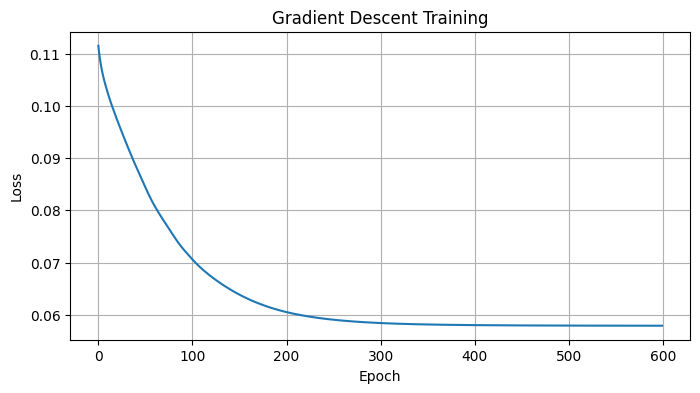

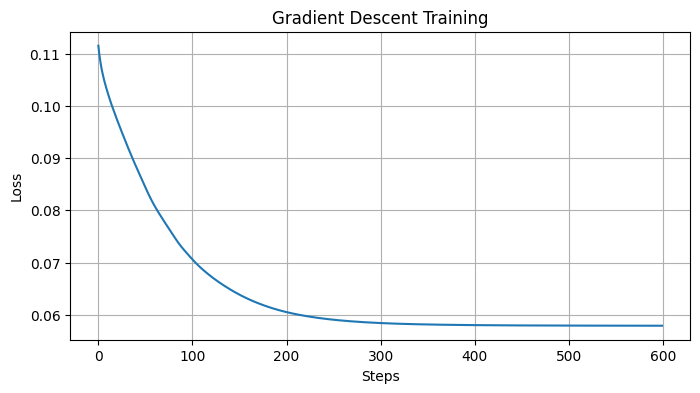

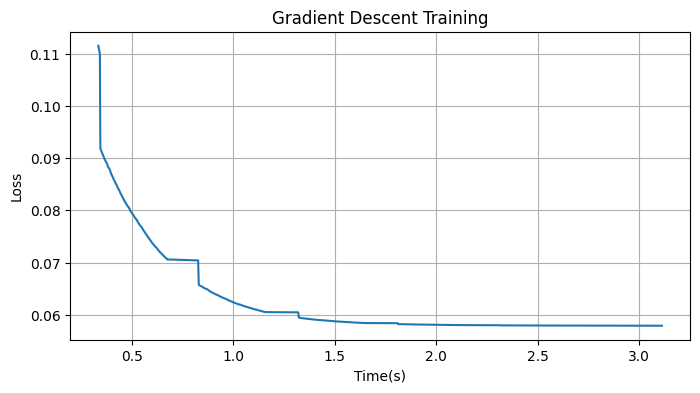

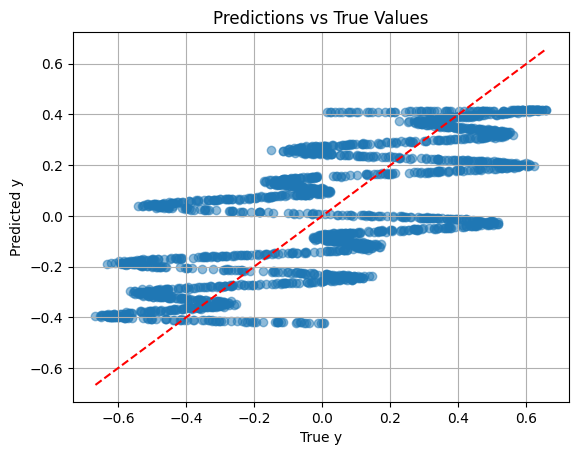

In [14]:
#Gradient Descent - full batch, one step per epoch
# Simple update
def gd_update(params, grads, learning_rate):
    """Update parameters using GD."""
    return jax.tree.map(
        #understand jax tree map: jax.tree.map(f, tree, *rest, is_leaf=None) - I need this bc of the form jax.grad gives me.
        #p = parameter, g=gradient; lambda creates namless funtion to update p
        lambda p, g: p - learning_rate * g,
        params, grads
    )

#JIT compile the training step for speed
@jit
def train_step(params, X, Y, learning_rate):
    """Single training step."""
    loss, grads = jax.value_and_grad(loss_fn)(params, X, Y)
    params = gd_update(params, grads, learning_rate)
    return params, loss

# Training loop
key = random.PRNGKey(42)
params = init_mlp(key, [1, 128, 128, 1])

gd_losses = []
learning_rate = 0.02


gd_step_losses = []

gd_epoch_times=[]

start_time = time.time()

for epoch in range(600):
    params, loss = train_step(params, X, Y, learning_rate)
    gd_losses.append(loss)

    elapsed_time = time.time() - start_time

    gd_step_losses.append(loss)
    gd_epoch_times.append(elapsed_time)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d}: loss = {loss:.6f}")

print(f"\nFinal loss: {gd_losses[-1]:.6f}")
plt.figure(figsize=(8, 4))
plt.plot(gd_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Gradient Descent Training')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(gd_step_losses)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Gradient Descent Training')
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 4))
plt.plot(gd_epoch_times, gd_step_losses)
plt.xlabel('Time(s)')
plt.ylabel('Loss')
plt.title('Gradient Descent Training')
plt.grid(True)
plt.show()

y_pred = forward_batch(params, X)
plt.scatter(Y, y_pred, alpha=0.5)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('Predictions vs True Values')
plt.grid(True)


Epoch 0: avg loss = 0.119505
Epoch 20: avg loss = 0.066098
Epoch 40: avg loss = 0.058329
Epoch 60: avg loss = 0.057800
Epoch 80: avg loss = 0.057737
Epoch 100: avg loss = 0.057704
Epoch 120: avg loss = 0.057702
Epoch 140: avg loss = 0.057724
Epoch 160: avg loss = 0.057701
Epoch 180: avg loss = 0.057673
Epoch 200: avg loss = 0.057668
Epoch 220: avg loss = 0.057665
Epoch 240: avg loss = 0.057692
Epoch 260: avg loss = 0.057640
Epoch 280: avg loss = 0.057646
Epoch 300: avg loss = 0.057639
Epoch 320: avg loss = 0.057631
Epoch 340: avg loss = 0.057643
Epoch 360: avg loss = 0.057646
Epoch 380: avg loss = 0.057607


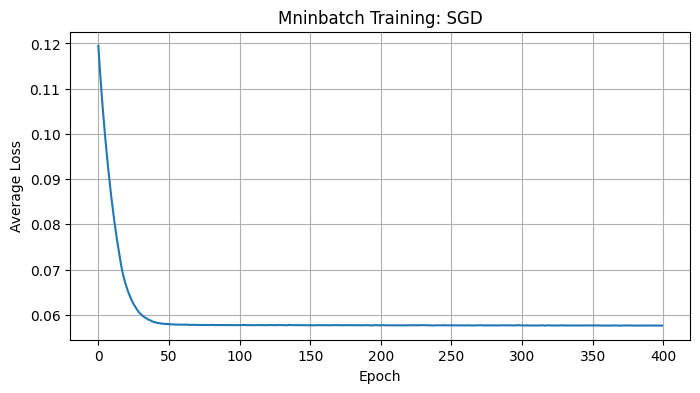

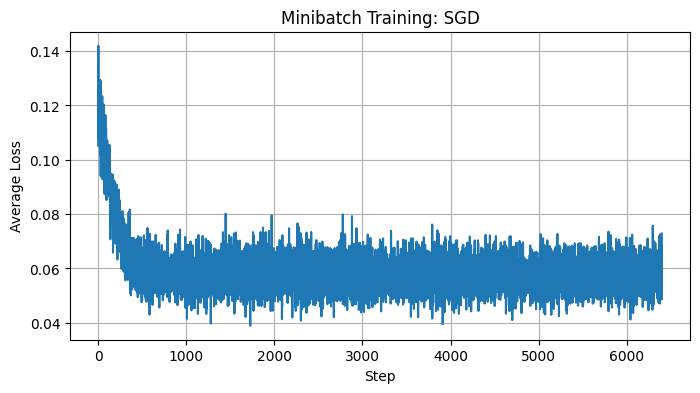

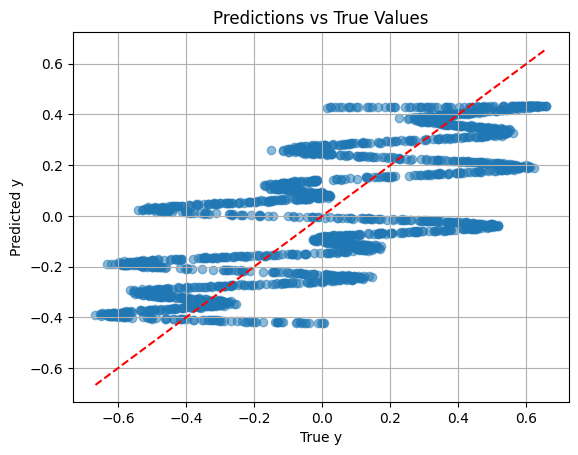

In [15]:
#Stochastic Gradient Descent - minibatches of 128, reshuffled every epoch, 400 epochs
def get_batches(x, y, batch_size, key):
    """Generate random mini-batches."""
    n_samples = x.shape[0]
    indices = random.permutation(key, n_samples)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        batch_indices = indices[start:end]
        yield x[batch_indices], y[batch_indices]

# Training with mini-batches
key = random.PRNGKey(0)
params = init_mlp(key, [1, 128, 128, 1])
learning_rate = 0.01

batch_size = 128
n_epochs = 400
sgd_losses = []

sgd_step_losses=[]

sgd_epoch_times=[]

start_time = time.time()

for epoch in range(n_epochs):
    key, subkey = random.split(key)
    epoch_losses = []

    for x_batch, y_batch in get_batches(X, Y, batch_size, subkey):
        params, loss = train_step(params, x_batch, y_batch, learning_rate)
        epoch_losses.append(loss)

        sgd_step_losses.append(loss)

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    sgd_losses.append(avg_loss)

    elapsed_time=time.time()-start_time

    sgd_epoch_times.append(elapsed_time)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: avg loss = {avg_loss:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(sgd_losses)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Mninbatch Training: SGD')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(sgd_step_losses)
plt.xlabel('Step')
plt.ylabel('Average Loss')
plt.title('Minibatch Training: SGD')
plt.grid(True)
plt.show()

y_pred = forward_batch(params, X)
plt.scatter(Y, y_pred, alpha=0.5)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('Predictions vs True Values')
plt.grid(True)



Epoch 0: avg loss = 0.121760
Epoch 20: avg loss = 0.073277
Epoch 40: avg loss = 0.058201
Epoch 60: avg loss = 0.057849
Epoch 80: avg loss = 0.057826
Epoch 100: avg loss = 0.057817
Epoch 120: avg loss = 0.057814
Epoch 140: avg loss = 0.057804
Epoch 160: avg loss = 0.057801
Epoch 180: avg loss = 0.057800
Epoch 200: avg loss = 0.057788
Epoch 220: avg loss = 0.057783
Epoch 240: avg loss = 0.057780
Epoch 260: avg loss = 0.057774
Epoch 280: avg loss = 0.057766
Epoch 300: avg loss = 0.057758
Epoch 320: avg loss = 0.057763
Epoch 340: avg loss = 0.057750
Epoch 360: avg loss = 0.057744
Epoch 380: avg loss = 0.057738


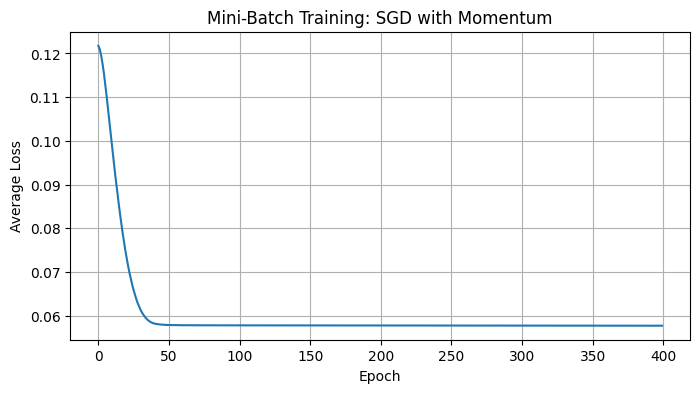

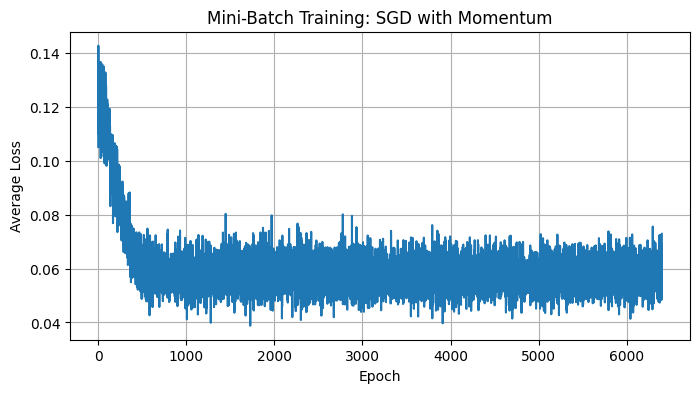

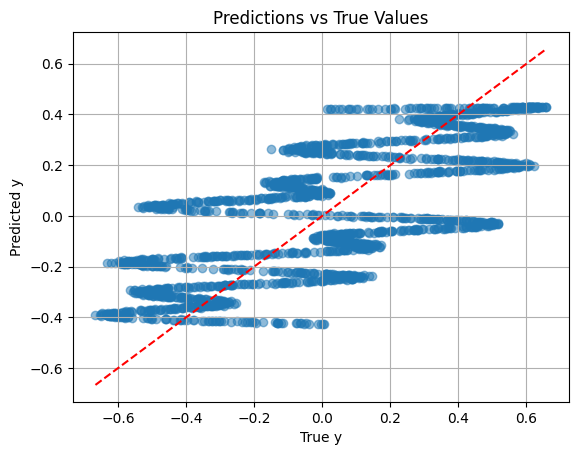

In [12]:
#Stochastic Gradient Descent - minibatches of 128, reshuffled every epoch, 400 epochs
#With Momentum

def m_update(momentum, grads, beta):
    """Update parameters using GD."""
    return jax.tree.map(
        lambda m, g: beta*m + (1-beta) * g,
        momentum, grads
    )

def sgdm_update(params, momentum, learning_rate):
    """Update parameters using GD."""
    return jax.tree.map(
        lambda p, m: p - learning_rate * m,
        params, momentum
    )

# JIT compile the training step for speed
@jit
def train_step(params, momentum, X, Y, learning_rate):
    """Single training step."""
    loss, grads = jax.value_and_grad(loss_fn)(params, X, Y)
    momentum=m_update(momentum, grads, beta)
    params = sgdm_update(params, momentum, learning_rate)
    return params, momentum, loss



def get_batches(x, y, batch_size, key):
    """Generate random mini-batches."""
    n_samples = x.shape[0]
    indices = random.permutation(key, n_samples)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        batch_indices = indices[start:end]
        yield x[batch_indices], y[batch_indices]

# Training with mini-batches
key = random.PRNGKey(0)
params = init_mlp(key, [1, 128, 128, 1])
momentum = jax.tree.map(jnp.zeros_like, params)
learning_rate = 0.01
beta=0.99
batch_size = 128
n_epochs = 400
sgd_momentum_losses = []

sgd_momentum_step_losses = []

sgd_momentum_epoch_times=[]

start_time = time.time()


for epoch in range(n_epochs):
    key, subkey = random.split(key)
    epoch_losses = []

    for x_batch, y_batch in get_batches(X, Y, batch_size, subkey):
        params, momentum, loss = train_step(params, momentum, x_batch, y_batch, learning_rate)
        epoch_losses.append(loss)


        sgd_momentum_step_losses.append(loss)

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    sgd_momentum_losses.append(avg_loss)

    elapsed_time=time.time()-start_time

    sgd_momentum_epoch_times.append(elapsed_time)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: avg loss = {avg_loss:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(sgd_momentum_losses)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Mini-Batch Training: SGD with Momentum')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(sgd_momentum_step_losses)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Mini-Batch Training: SGD with Momentum')
plt.grid(True)
plt.show()

y_pred = forward_batch(params, X)
plt.scatter(Y, y_pred, alpha=0.5)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('Predictions vs True Values')
plt.grid(True)


Epoch 0: avg loss = 0.079941
Epoch 20: avg loss = 0.058351
Epoch 40: avg loss = 0.057754
Epoch 60: avg loss = 0.057679
Epoch 80: avg loss = 0.057547
Epoch 100: avg loss = 0.057268
Epoch 120: avg loss = 0.057163
Epoch 140: avg loss = 0.056977
Epoch 160: avg loss = 0.056578
Epoch 180: avg loss = 0.056182
Epoch 200: avg loss = 0.055865
Epoch 220: avg loss = 0.055519
Epoch 240: avg loss = 0.055278
Epoch 260: avg loss = 0.054881
Epoch 280: avg loss = 0.054609
Epoch 300: avg loss = 0.054198
Epoch 320: avg loss = 0.053807
Epoch 340: avg loss = 0.053484
Epoch 360: avg loss = 0.053071
Epoch 380: avg loss = 0.052568


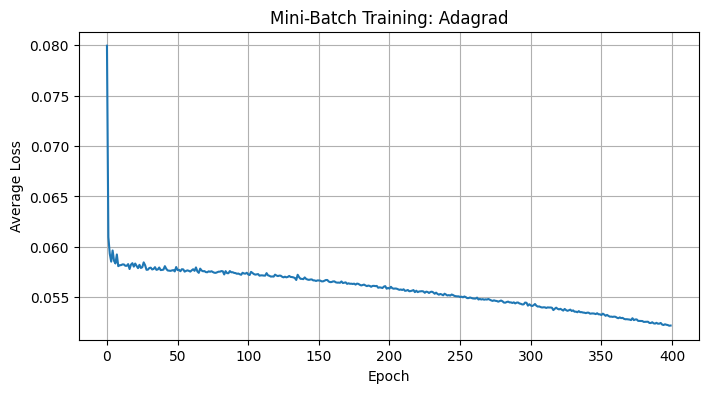

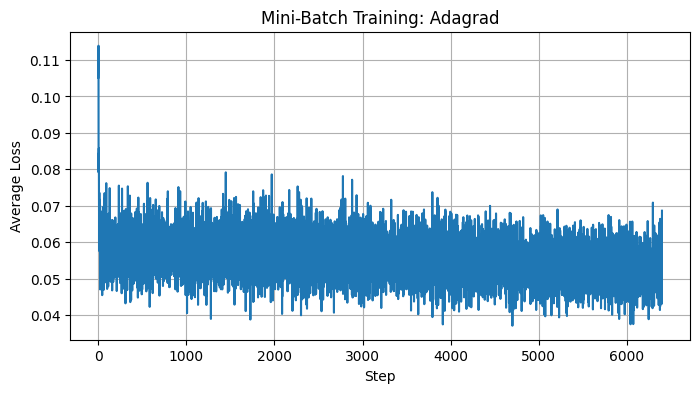

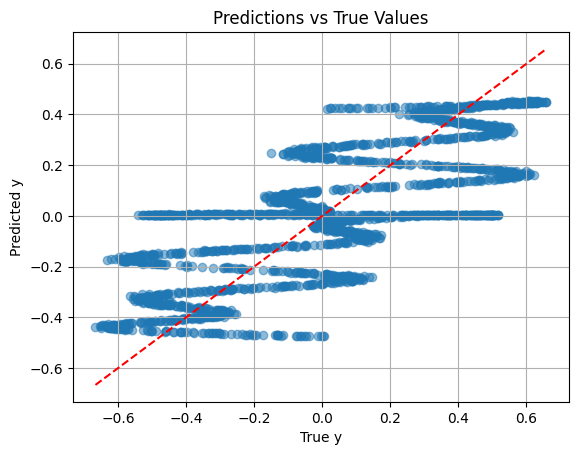

In [11]:
#AdaGrad
#Stochastic Gradient Descent - minibatches of 128, reshuffled every epoch, 400 epochs

def G_update(squaredgrads, grads):
    """Update parameters using GD."""
    return jax.tree.map(
        lambda G, g: G + g**2,
        squaredgrads, grads
    )

def adagrad_update(params, epsilon, squaredgrads, learning_rate, grads):
    """Update parameters using GD."""
    return jax.tree.map(
        lambda p, G, g: p - (learning_rate*1/(jnp.sqrt(G)+epsilon)) * g,
        params, squaredgrads, grads
    )

#JIT compile the training step for speed
@jit
def train_step(params, squaredgrads, X, Y, learning_rate):
    """Single training step."""
    loss, grads = jax.value_and_grad(loss_fn)(params, X, Y) #Get Loss and grad for given loss fct, data and params
    squaredgrads=G_update(squaredgrads, grads)
    params = adagrad_update(params, epsilon, squaredgrads, learning_rate, grads)
    return params, squaredgrads, loss



def get_batches(x, y, batch_size, key):
    """Generate random mini-batches."""
    n_samples = x.shape[0]
    indices = random.permutation(key, n_samples)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        batch_indices = indices[start:end]
        yield x[batch_indices], y[batch_indices]

# Training with mini-batches
key = random.PRNGKey(0)
params = init_mlp(key, [1, 128, 128, 1])
squaredgrads = jax.tree.map(jnp.zeros_like, params)
learning_rate = 0.01
epsilon=0.01
batch_size = 128
n_epochs = 400
adagrad_losses = []

adagrad_step_losses= []

adagrad_epoch_times = []

start_time = time.time()


for epoch in range(n_epochs):
    key, subkey = random.split(key)
    epoch_losses = []

    for x_batch, y_batch in get_batches(X, Y, batch_size, subkey):
        params, squaredgrads, loss = train_step(params, squaredgrads, x_batch, y_batch, learning_rate)
        epoch_losses.append(loss)

        adagrad_step_losses.append(loss)

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    adagrad_losses.append(avg_loss)

    elapsed_time=time.time()-start_time
    adagrad_epoch_times.append(elapsed_time)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: avg loss = {avg_loss:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(adagrad_losses)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Mini-Batch Training: Adagrad')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(adagrad_step_losses)
plt.xlabel('Step')
plt.ylabel('Average Loss')
plt.title('Mini-Batch Training: Adagrad')
plt.grid(True)
plt.show()

y_pred = forward_batch(params, X)
plt.scatter(Y, y_pred, alpha=0.5)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('Predictions vs True Values')
plt.grid(True)


Epoch 0: avg loss = 0.112706
Epoch 20: avg loss = 0.059088
Epoch 40: avg loss = 0.059316
Epoch 60: avg loss = 0.058225
Epoch 80: avg loss = 0.057819
Epoch 100: avg loss = 0.057525
Epoch 120: avg loss = 0.053769
Epoch 140: avg loss = 0.047762
Epoch 160: avg loss = 0.045050
Epoch 180: avg loss = 0.041707
Epoch 200: avg loss = 0.036976
Epoch 220: avg loss = 0.033181
Epoch 240: avg loss = 0.030867
Epoch 260: avg loss = 0.028286
Epoch 280: avg loss = 0.026602
Epoch 300: avg loss = 0.026111
Epoch 320: avg loss = 0.024257
Epoch 340: avg loss = 0.026083
Epoch 360: avg loss = 0.022026
Epoch 380: avg loss = 0.021920


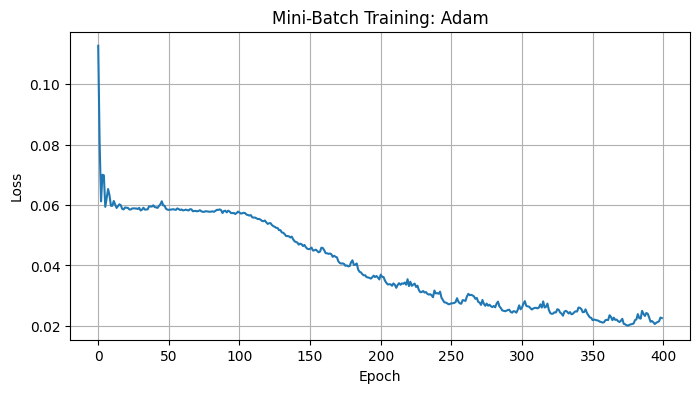

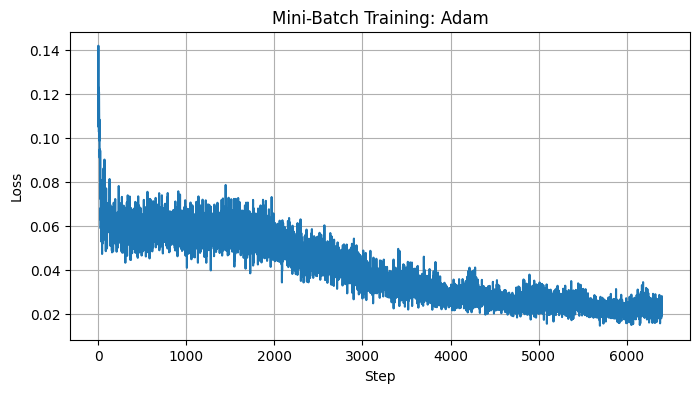

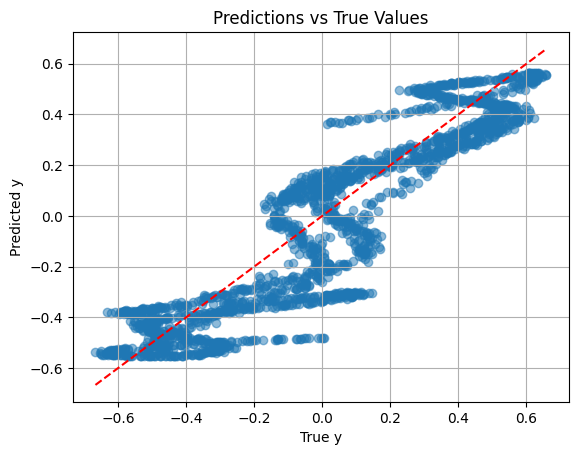

In [10]:
#Adam
#Stochastic Gradient Descent - minibatches of 128, reshuffled every epoch, 400 epochs
#With Momentum
def m_update(momentum, grads, beta1):
    """Update parameters using GD."""
    return jax.tree.map(
        lambda m, g: beta1*m + (1-beta1) * g,
        momentum, grads
    )

def G_update(squaredgrads, grads, beta2):
    """Update parameters using GD."""
    return jax.tree.map(
        lambda G, g: beta2*G + (1-beta2)*g**2,
        squaredgrads, grads
    )

def adam_update(params, epsilon, squaredgrads, learning_rate, momentum):
    """Update parameters using GD."""
    return jax.tree.map(
        lambda p, G, m: p - (learning_rate*m)/(jnp.sqrt(G)+epsilon),
        params, squaredgrads, momentum
    )

# JIT compile the training step for speed
@jit
def train_step(params, squaredgrads, momentum, X, Y, learning_rate):
    """Single training step."""
    loss, grads = jax.value_and_grad(loss_fn)(params, X, Y) #understand jax values and grads
    squaredgrads=G_update(squaredgrads, grads, beta2)
    momentum=m_update(momentum, grads, beta1)
    params = adam_update(params, epsilon, squaredgrads, learning_rate, momentum)
    return params, squaredgrads, momentum, loss



def get_batches(x, y, batch_size, key):
    """Generate random mini-batches."""
    n_samples = x.shape[0]
    indices = random.permutation(key, n_samples)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        batch_indices = indices[start:end]
        yield x[batch_indices], y[batch_indices]

# Training with mini-batches
key = random.PRNGKey(0)
params = init_mlp(key, [1, 128, 128, 1])
squaredgrads = jax.tree.map(jnp.zeros_like, params)
momentum = jax.tree.map(jnp.zeros_like, params)
learning_rate = 0.01
beta1=0.99
beta2=0.99
epsilon=0.01
batch_size = 128
n_epochs = 400
adam_losses = []
epoch_num=[]

adam_step_losses = []

adam_epoch_times=[]

start_time = time.time()

for epoch in range(n_epochs):
    key, subkey = random.split(key)
    epoch_losses = []


    for x_batch, y_batch in get_batches(X, Y, batch_size, subkey):
        params, squaredgrads, momentum, loss = train_step(params, squaredgrads, momentum, x_batch, y_batch, learning_rate)
        epoch_losses.append(loss)

        adam_step_losses.append(loss)

    elapsed_time=time.time()-start_time
    adam_epoch_times.append(elapsed_time)

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    adam_losses.append(avg_loss)
    epoch_num.append(epoch)

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: avg loss = {avg_loss:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(adam_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Mini-Batch Training: Adam')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(adam_step_losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Mini-Batch Training: Adam')
plt.grid(True)
plt.show()

y_pred = forward_batch(params, X)
plt.scatter(Y, y_pred, alpha=0.5)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('Predictions vs True Values')
plt.grid(True)


Epoch   0 | Avg Loss: 0.092923
Epoch  20 | Avg Loss: 0.049774
Epoch  40 | Avg Loss: 0.031285
Epoch  60 | Avg Loss: 0.026948
Epoch  80 | Avg Loss: 0.024002
Epoch 100 | Avg Loss: 0.021672
Epoch 120 | Avg Loss: 0.020107
Epoch 140 | Avg Loss: 0.015888
Epoch 160 | Avg Loss: 0.015140
Epoch 180 | Avg Loss: 0.010863
Epoch 200 | Avg Loss: 0.010890
Epoch 220 | Avg Loss: 0.008991
Epoch 240 | Avg Loss: 0.008156
Epoch 260 | Avg Loss: 0.010288
Epoch 280 | Avg Loss: 0.007111
Epoch 300 | Avg Loss: 0.010308
Epoch 320 | Avg Loss: 0.009399
Epoch 340 | Avg Loss: 0.008690
Epoch 360 | Avg Loss: 0.007778
Epoch 380 | Avg Loss: 0.008579
Epoch 399 | Avg Loss: 0.007337

Training finished in 14.46 seconds.


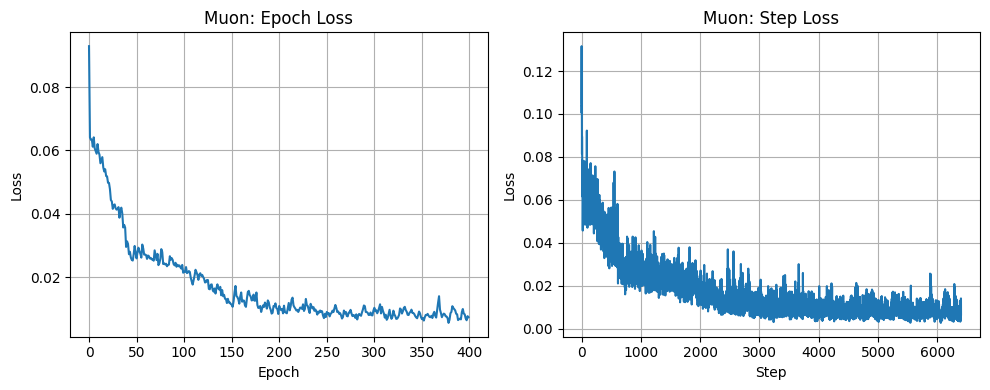

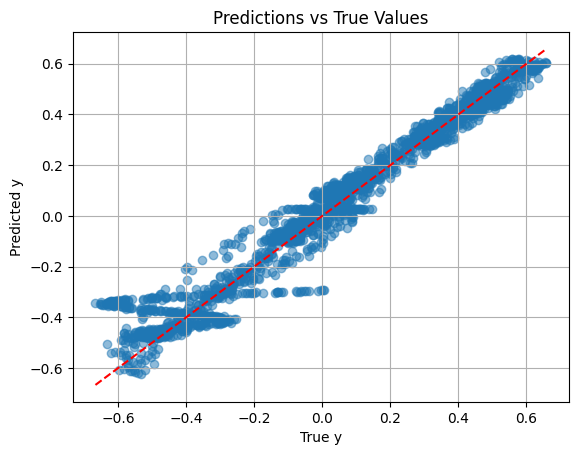

In [9]:
# Muon

import time
import jax
import jax.numpy as jnp
from jax import jit, random
import matplotlib.pyplot as plt

# taken from his given code on github link
def newton_schulz5(G, steps=5, eps=1e-7):
    """
    Newton-Schulz iteration (quintic polynomial degree 5) from Keller Jordan's specification.
    Approximates the nearest orthogonal matrix for 2D weight updates.
    """
    orig_ndim = G.ndim
    if orig_ndim == 1:
        G = G[:, None]  # Promote 1D vectors to 2D column matrices

    a, b, c = 3.4445, -4.7750, 2.0315
    X = G / (jnp.linalg.norm(G) + eps)

    # Transpose tall matrices upfront to optimize inner matrix products: X @ X.T
    is_tall = X.shape[0] > X.shape[1]
    if is_tall:
        X = X.T

    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * (A @ A)
        X = a * X + B @ X

    if is_tall:
        X = X.T
    return X.squeeze(-1) if orig_ndim == 1 else X

@jit
def train_step(params, B, X, Y, lr, mu):
    """
    Single Muon update step:
      1. G_t = grad(loss)(params)
      2. B_t = mu * B_{t-1} + G_t
      3. theta_t = theta_{t-1} - lr * NewtonSchulz5(B_t)
    """
    loss, grads = jax.value_and_grad(loss_fn)(params, X, Y)

    # Update momentum buffer: B_t = mu * B_{t-1} + G_t
    B = jax.tree.map(lambda b, g: mu * b + g, B, grads)

    # Update parameters: theta_t = theta_{t-1} - eta * NewtonSchulz5(B_t)
    params = jax.tree.map(lambda p, b: p - lr * newton_schulz5(b), params, B)

    return params, B, loss


def get_batches(x, y, batch_size, key):
    """Yield mini-batches with reshuffled indices each epoch."""
    n_samples = x.shape[0]
    indices = random.permutation(key, n_samples)
    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        batch_idx = indices[start:end]
        yield x[batch_idx], y[batch_idx]


key = random.PRNGKey(0)
params = init_mlp(key, [1, 128, 128, 1])

# Initialize momentum buffer B_0 = 0
B = jax.tree.map(jnp.zeros_like, params)

# Hyperparameters
lr = 0.02          # Learning rate (eta)
mu = 0.95          # Momentum factor
batch_size = 128
n_epochs = 400

epoch_losses = []
step_losses = []
muon_epoch_times = []

start_time = time.time()

for epoch in range(n_epochs):
    key, subkey = random.split(key)
    batch_losses = []

    for x_batch, y_batch in get_batches(X, Y, batch_size, subkey):
        params, B, loss = train_step(params, B, x_batch, y_batch, lr, mu)
        batch_losses.append(loss)
        step_losses.append(loss)

    avg_loss = sum(batch_losses) / len(batch_losses)
    epoch_losses.append(avg_loss)

    elapsed_time = time.time() - start_time
    muon_epoch_times.append(elapsed_time)

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:3d} | Avg Loss: {avg_loss:.6f}")

print(f"\nTraining finished in {time.time() - start_time:.2f} seconds.")
muon_losses = epoch_losses
muon_step_losses = step_losses

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epoch_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Muon: Epoch Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(step_losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Muon: Step Loss")
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = forward_batch(params, X)
plt.scatter(Y, y_pred, alpha=0.5)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('Predictions vs True Values')
plt.grid(True)

---
## 4. What to report

- **All six loss curves on one set of axes**, log scale on y. Plot against both epochs and steps

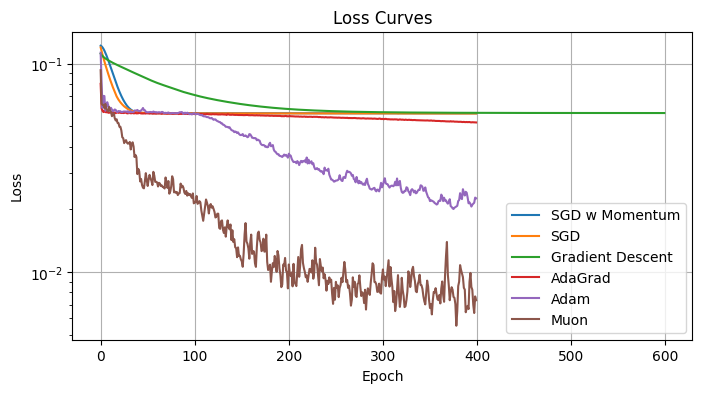

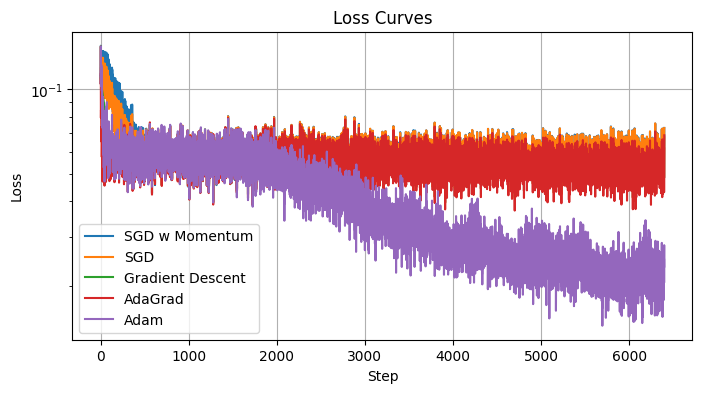

In [ ]:


plt.figure(figsize=(8, 4))
plt.plot(sgd_momentum_losses, label="SGD w Momentum")
plt.plot(sgd_losses, label="SGD")
plt.plot(gd_losses,label="Gradient Descent")
plt.plot(adagrad_losses, label="AdaGrad")
plt.plot(adam_losses,label="Adam")
plt.plot(muon_losses,label="Muon")
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(sgd_momentum_step_losses, label="SGD w Momentum")
plt.plot(sgd_step_losses, label="SGD")
plt.plot(gd_step_losses,label="Gradient Descent")
plt.plot(adagrad_step_losses, label="AdaGrad")
plt.plot(adam_step_losses,label="Adam")
#plt.plot(muon_losses,label="Muon")
plt.yscale('log')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

---
## 5. One more plot

Now make a plot I did not ask for.



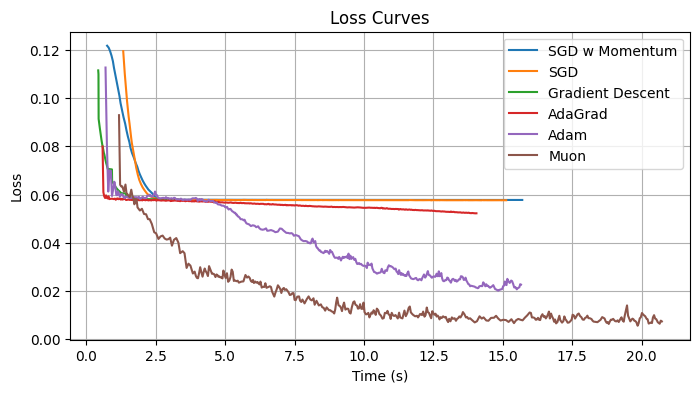

In [ ]:
# Plotting vs time spent for each epoch
plt.figure(figsize=(8, 4))
plt.plot(sgd_momentum_epoch_times, sgd_momentum_losses, label="SGD w Momentum")
plt.plot(sgd_epoch_times, sgd_losses, label="SGD")
plt.plot(gd_epoch_times, gd_losses,label="Gradient Descent")
plt.plot(adagrad_epoch_times, adagrad_losses, label="AdaGrad")
plt.plot(adam_epoch_times, adam_losses,label="Adam")
plt.plot(muon_epoch_times, muon_losses,label="Muon")
plt.xlabel('Time (s)')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Also added true vs. predicted Y for each optimization model.